In [1]:
import torch
torch.__version__

'2.5.1+cu121'

In [2]:
%pip install transformers
%pip install timm
%pip install packaging
%pip install wheel
%pip install ninja
%pip install flash_attn
%pip install einops
%pip install accelerate

  Using cached tokenizers-0.21.4-cp39-abi3-win_amd64.whl.metadata (6.9 kB)
Using cached tokenizers-0.21.4-cp39-abi3-win_amd64.whl (2.5 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.20.3
    Uninstalling tokenizers-0.20.3:
      Successfully uninstalled tokenizers-0.20.3
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cohere 5.15.0 requires types-requests<3.0.0,>=2.0.0, which is not installed.
chromadb 0.5.23 requires tokenizers<=0.20.3,>=0.13.2, but you have tokenizers 0.21.4 which is incompatible.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached ninja-1.13.0-py3-none-win_amd64.whl.metadata (5.1 kB)
Using cached ninja-1.13.0-py3-none-win_amd64.whl (309 kB)
Note: you may need to restart the kernel to use updated packages.
     ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
     ------------ --------------------------- 2.6/8.4 MB 21.4 MB/s eta 0:00:01
     ---------------------------------------- 8.4/8.4 MB 26.2 MB/s  0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for flash_attn
Failed to build flash_attn
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'flash_attn' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'flash_attn'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [224 lines of output]
      
      
      torch.__version__  = 2.5.1+cu121
      
      
      c:\Users\Ivan\AppData\Local\Programs\Python\Python312\Lib\site-packages\setuptools\__init__.py:92: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
      !!
      
              ********************************************************************************
              Requirements sh


Note: you may need to restart the kernel to use updated packages.


In [12]:
import textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageDraw, ImageFont
from transformers import AutoProcessor, AutoModelForCausalLM
from io import BytesIO
import requests

In [13]:
model_id = 'microsoft/Florence-2-large'
#model_id = 'microsoft/Florence-2-base'

model = AutoModelForCausalLM.from_pretrained(model_id,
                                             trust_remote_code=True).eval()
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

In [15]:
def florence2(task_prompt, images, text_input=None):
    """
    Calling the Microsoft Florence2 model
    """
    if text_input is None:
        prompt = task_prompt
    else:
        prompt = task_prompt + text_input

    inputs = processor(text=prompt, images=image, return_tensors="pt")

    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=1024,
        early_stopping=False,
        do_sample=False,
        num_beams=3,
    )
    generated_text = processor.batch_decode(generated_ids,
                                            skip_special_tokens=False)[0]
    parsed_answer = processor.post_process_generation(
        generated_text,
        task=task_prompt,
        image_size=(image.width, image.height))

    return parsed_answer

A man standing next to a tiger in a forest.


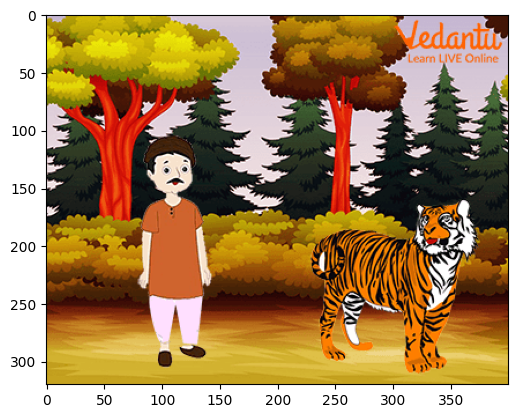

In [17]:
task_prompt = '<CAPTION>'
url = "https://www.vedantu.com/seo/content-images/c6ec2ee5-dd61-4028-b883-52b492a7d8a1.png"
response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert('RGB')
caption1 = list(florence2(task_prompt, image).values())[0]
print(caption1)
plt.imshow(image)

The image shows a cartoon illustration of a young boy standing in a
park with a tiger. The boy is wearing a brown t-shirt, white pants,
and a brown cap. He has a mustache and is standing in front of a large
tree with orange and yellow leaves. The tiger is standing on its hind
legs and is looking at the boy with a curious expression. The
background is filled with trees and bushes, and the sky is blue. The
image is accompanied by the text "Vedantu Learn Live Online".


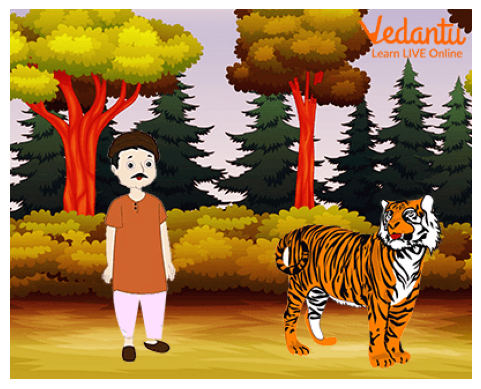

In [18]:
task_prompt2 = '<MORE_DETAILED_CAPTION>'
long_caption1 = list(florence2(task_prompt2, image).values())[0]

print('\n'.join(textwrap.wrap(long_caption1)))

plt.imshow(image);
plt.axis('off');

In [19]:
task_prompt3 = '<OD>'
od_results = florence2(task_prompt3, image)  
od_results['<OD>']

{'bboxes': [[92.20000457763672,
   120.15999603271484,
   127.4000015258789,
   154.72000122070312],
  [75.4000015258789, 105.1199951171875, 146.1999969482422, 304.79998779296875],
  [228.1999969482422,
   160.47999572753906,
   374.6000061035156,
   310.55999755859375]],
 'labels': ['human face', 'person', 'tiger']}

In [20]:
def plot_bbox(image, data):
    fig, ax = plt.subplots()

    # Display the image
    ax.imshow(image)

    # Plot each bounding box
    for bbox, label in zip(data['bboxes'], data['labels']):
        # Unpack the bounding box coordinates
        x1, y1, x2, y2 = bbox
        # Create a Rectangle patch
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='r', facecolor='none')
        # Add the rectangle to the Axes
        ax.add_patch(rect)
        # Annotate the label
        plt.text(x1, y1, label, color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))

    # Remove the axis ticks and labels
    ax.axis('off')

    # Show the plot
    plt.show()

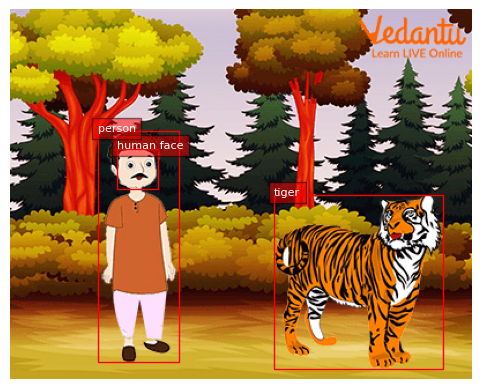

In [21]:
plot_bbox(image, od_results['<OD>']);

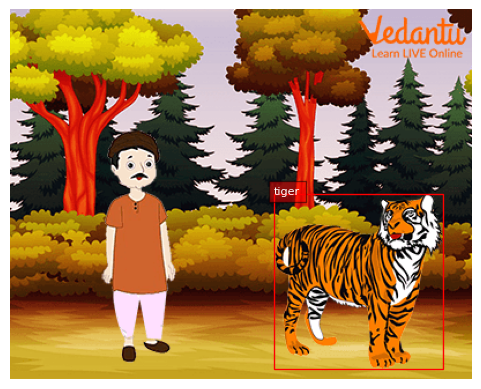

In [23]:
task_prompt4 = "<CAPTION_TO_PHRASE_GROUNDING>"

result = florence2(task_prompt4, image, text_input="tiger")

plot_bbox(image, result['<CAPTION_TO_PHRASE_GROUNDING>']);

In [36]:
task_prompt = '<OCR>'
image = Image.open("page_001.jpg")
results_ocr = florence2(task_prompt,image)
print(results_ocr)

{'<OCR>': "Alberta\n3D Timesheet\nPeriod summary\nResource\nYau, Ambrose\n Period End\nSubmitted on\nApproved on\nperiod Start\n2023-06-01\n202023-07-12\n2022-07 -14\nProject summary\nProject\nRemote\nHours\nDigital Meeting Experience (DMX)\n56.50\n98.50.\nHousing Partner Portal\n155.00\nActivity Details\nDate\nActivity\nType\nHour\n0.25\n2033-06 -01\nCCO e-Committees Stand-Up\nDigital Meeting Experience\n0,25\nDaily Standup - Housing Digital Services\nDMMX\nHousing Partner Portal - Remote\n0:50\n20323-05\nDMX weak iterations\nDigital Meetings Experience\nRemote\n1.75\nStep 2\nHDS-5297 - Screen: Request a Budget Amendment\nHOUSING Partner Portal . Remote\n4,00\n20333-05-02\nPrivate Non-Profit Portal Design Review\nHousesing Partner Portal\n1,000\nCCO e- Committees Stand-up\nDMDX\nDigital Messing Experience\nremote\n02023-08-02 - Daily Standup-Housing Partnership Portal\nRemote0.50 -0\nDesign System Drop-in hours\nHouting Partner Portal.\n0\n2043-06.02\nDMIX\nDesign Week's Iterations\nD

In [42]:
task_prompt = '<OCR_WITH_REGION>'

results_ocr = florence2(task_prompt,image)

print(results_ocr)

{'<OCR_WITH_REGION>': {'quad_boxes': [[97.75, 97.9000015258789, 410.5500183105469, 97.9000015258789, 410.5500183105469, 190.3000030517578, 97.75, 190.3000030517578], [1343.85009765625, 137.5, 1603.9500732421875, 137.5, 1603.9500732421875, 179.3000030517578, 1343.85009765625, 179.3000030517578], [96.05000305175781, 232.10000610351562, 318.75, 234.3000030517578, 318.75, 265.1000061035156, 96.05000305175781, 262.8999938964844], [96.05000305175781, 293.70001220703125, 221.85000610351562, 293.70001220703125, 221.85000610351562, 322.3000183105469, 96.05000305175781, 322.3000183105469], [97.75, 350.8999938964844, 274.5500183105469, 350.8999938964844, 274.5500183105469, 381.70001220703125, 97.75, 381.70001220703125], [96.05000305175781, 410.3000183105469, 243.95001220703125, 410.3000183105469, 243.95001220703125, 441.1000061035156, 96.05000305175781, 441.1000061035156], [471.75, 410.3000183105469, 614.5499877929688, 410.3000183105469, 614.5499877929688, 441.1000061035156, 471.75, 441.100006103

In [43]:
def draw_ocr_bboxes(image, prediction):
    """
    Draw OCR BBox
    """
    scale = 1
    draw = ImageDraw.Draw(image)
    bboxes, labels = prediction['quad_boxes'], prediction['labels']

    for box, label in zip(bboxes, labels):
        color = 'lime'
        new_box = (np.array(box) * scale).tolist()
        draw.polygon(new_box, width=4, outline=color)
        draw.text((new_box[0] + 8, new_box[1] + 2),
                  "{}".format(label),
                  align="right",
                  fill=color)
    
    display(image)

In [44]:
print(results_ocr.keys())

dict_keys(['<OCR_WITH_REGION>'])


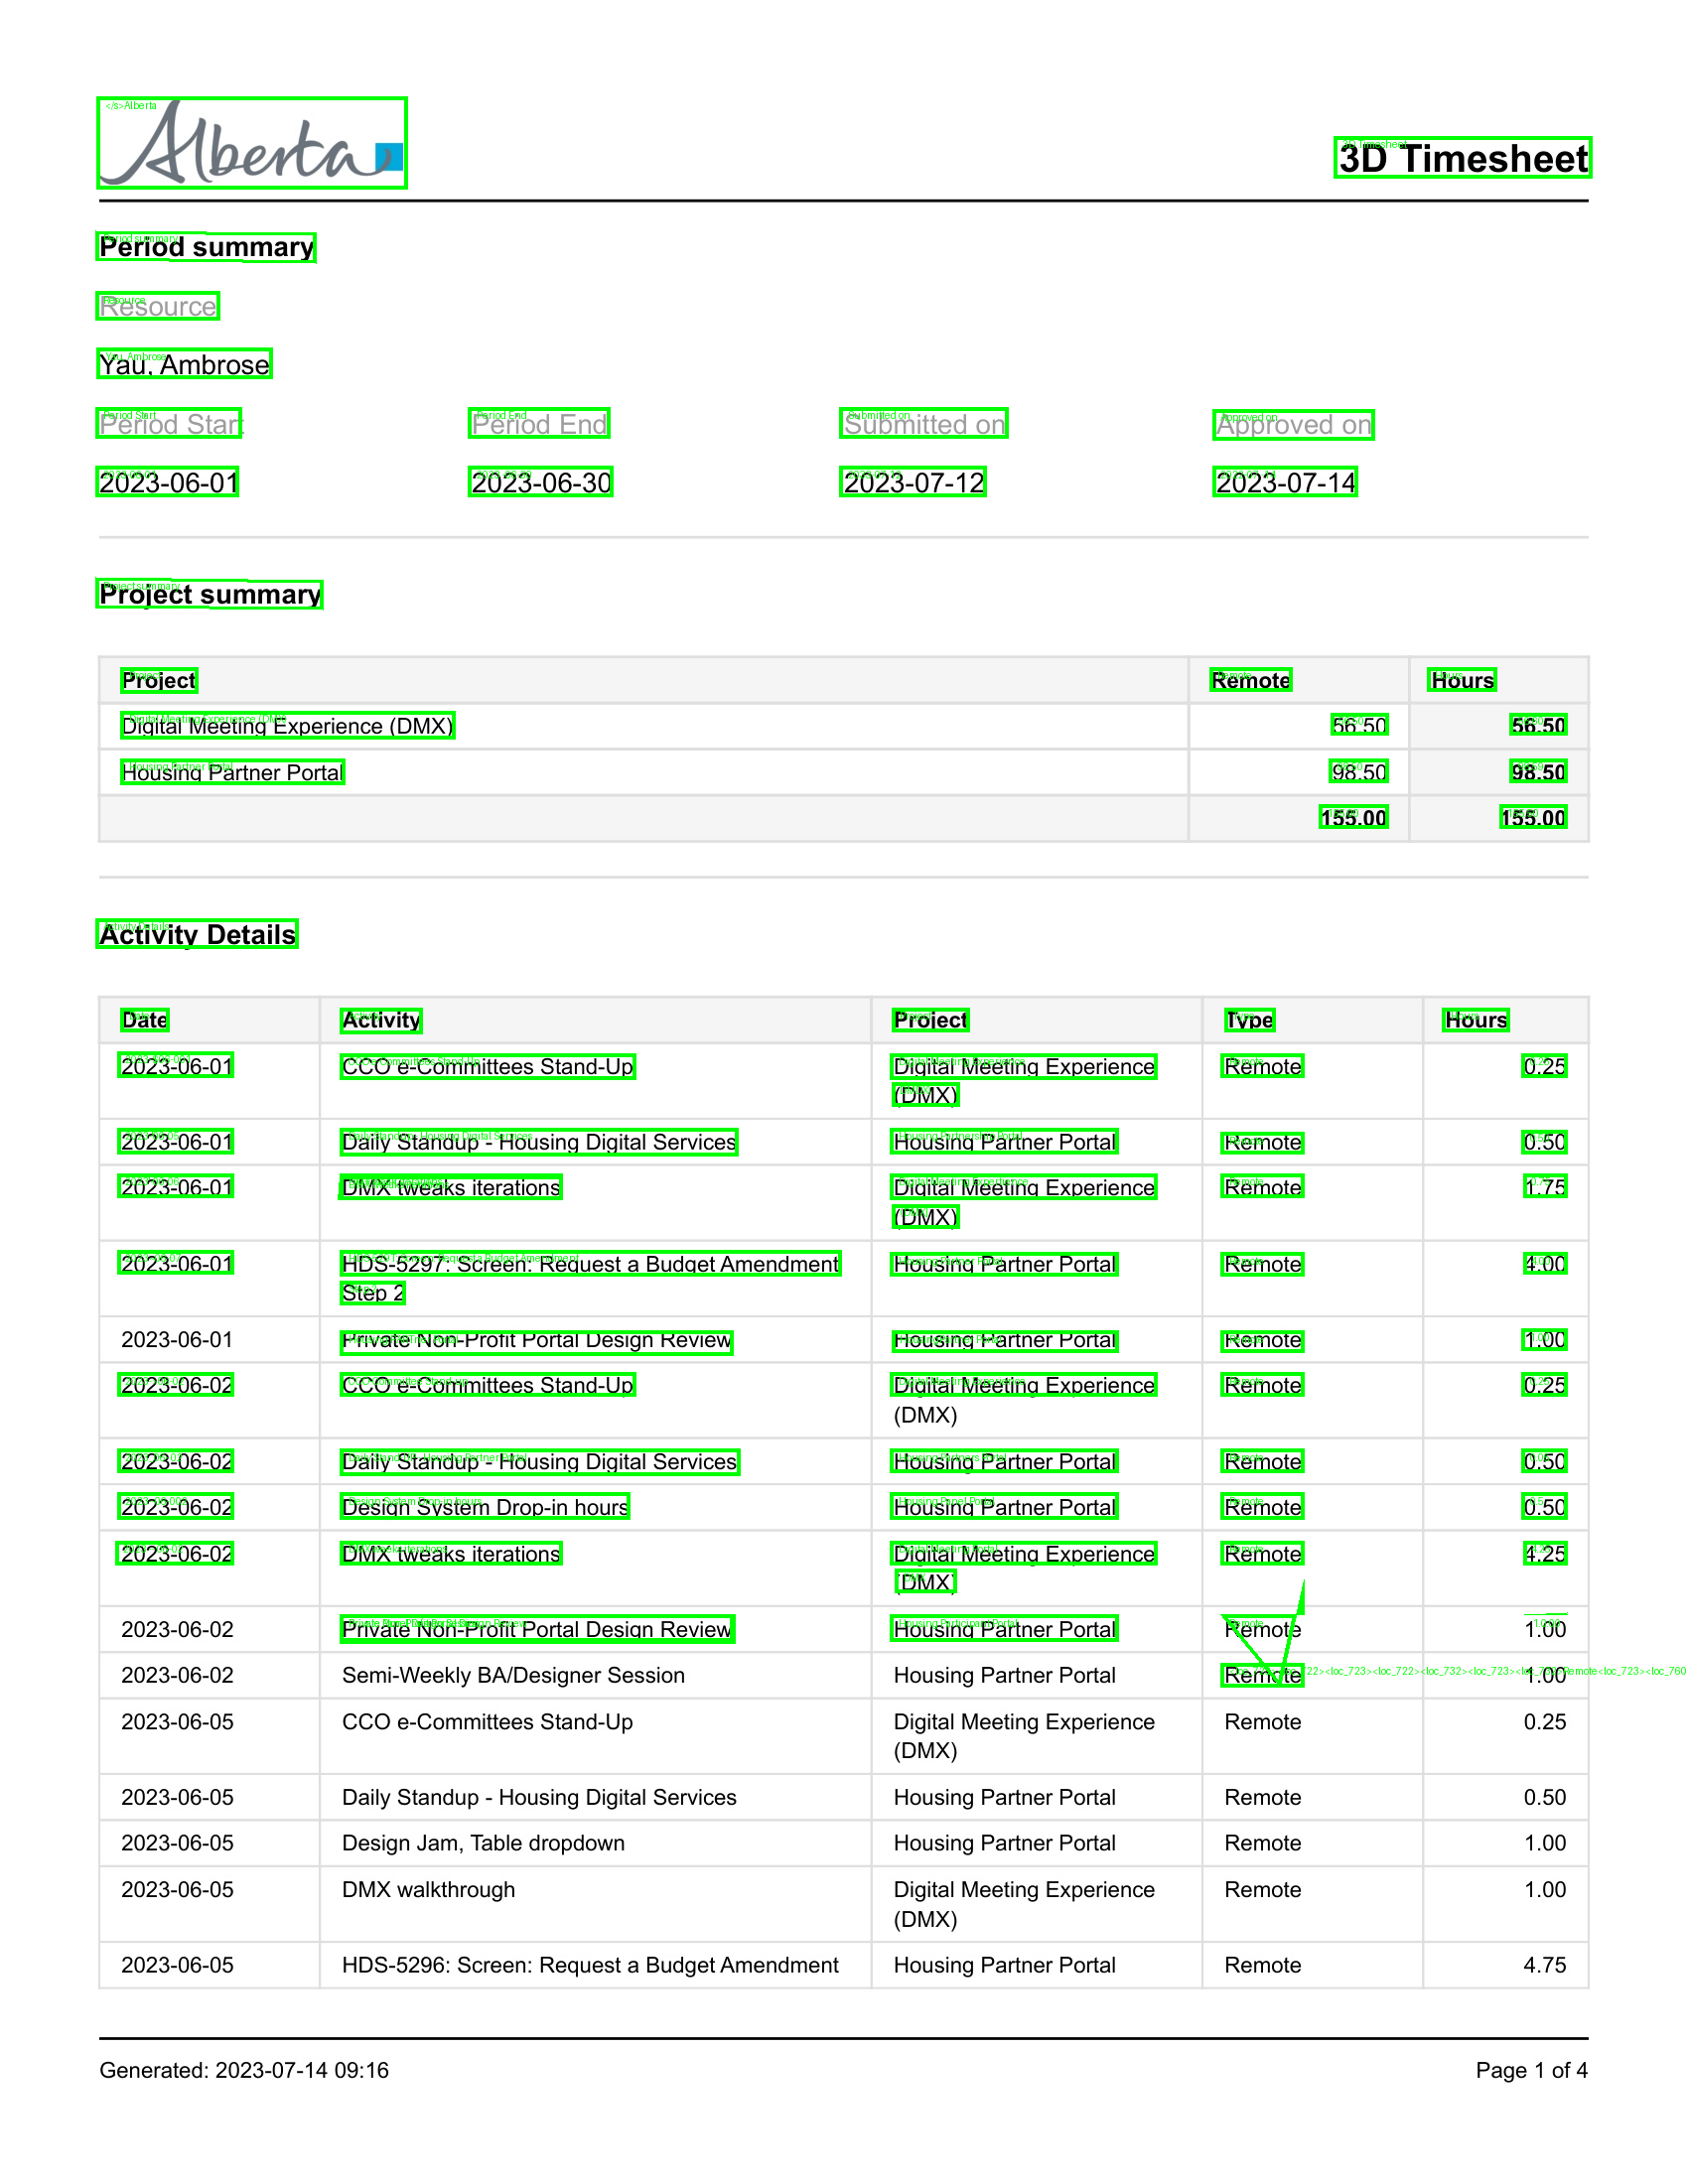

In [45]:
draw_ocr_bboxes(image, results_ocr['<OCR_WITH_REGION>'])